# Feature Ablation Study

## Objective

This notebook evaluates the contribution of each engineered feature group through systematic feature ablation.

Starting from the selected production feature set (V5), one feature group is removed at a time while keeping the Ridge Regression model and all remaining features unchanged.

The resulting changes in forecasting performance quantify the contribution of each feature engineering stage to the final production model.

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import duckdb

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)

In [4]:
DB_PATH = "../gridsight.duckdb"

TRAIN_END_DATE = "2025-12-31 23:00:00"
TEST_START_DATE = "2026-01-01 00:00:00"
TEST_END_DATE = "2026-06-30 23:00:00"

TARGET = "solar_generation_mw"

RANDOM_STATE = 42

BEST_ALPHA = 99.819268

## Load Dataset

In [6]:
with duckdb.connect(DB_PATH) as con:
    df = con.sql("""
        SELECT *
        FROM gold_training_dataset
        ORDER BY timestamp
    """).df()

## Train/Test Split

In [7]:
train_df = df[df["timestamp"] < TEST_START_DATE]

test_df = df[df["timestamp"] >= TEST_START_DATE]

In [8]:
### v0 Features

v0_features = [
    "solar_generation_mw_lag_1h",
    "solar_generation_mw_lag_24h",
    "solar_generation_mw_lag_168h"
]

### v1 Features

v1_features = v0_features + [
    "temperature_c",
    "relative_humidity_pct",
    "precipitation_mm",
    "cloud_cover_pct",
    "wind_speed_kmh",
    
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "direct_normal_irradiance"
]

### v2 Features

v2_features = v1_features + [
  "hour",
  "month",
  "day_of_week",
  "day_of_year",
  "is_weekend",
  "year"
]

### v3 Features

v3_features = v2_features + [
  "daylight_duration_hours",
  "sunshine_duration_hours",
  "is_daylight",
  "minutes_since_sunrise",
  "daylight_progress_pct",
]

### v4 Features

v4_features = v3_features + [
  "solar_generation_mw_roll_mean_3h",
  "solar_generation_mw_roll_mean_6h",
  "solar_generation_mw_roll_mean_24h",
  
  "solar_generation_mw_roll_std_3h",
  "solar_generation_mw_roll_std_6h",
  "solar_generation_mw_roll_std_24h",
  
  "solar_generation_mw_roll_min_3h",
  "solar_generation_mw_roll_min_6h",
  "solar_generation_mw_roll_min_24h",
  
  "solar_generation_mw_roll_max_3h",
  "solar_generation_mw_roll_max_6h",
  "solar_generation_mw_roll_max_24h"
]

### v5 Features

v5_features = v4_features + [
  "cloud_shortwave_interaction",
  "temperature_shortwave_interaction",
  "wind_temperature_interaction",
  "daylight_progress_shortwave_interaction"
]

feature_versions = {
  "V0": v0_features,
  "V1": v1_features,
  "V2": v2_features,
  "V3": v3_features,
  "V4": v4_features,
  "V5": v5_features
}

## Baseline Performance (V5)

In [9]:
ablation_sets = {
    "Baseline (V5)": v5_features,
    "Without Interaction Features": v4_features,
    "Without Rolling Features": v3_features,
    "Without Daylight Features": v2_features,
    "Without Calendar Features": v1_features,
    "Without Weather Features": v0_features
}

## Feature Ablation Experiments

Each experiment removes one engineered feature group while keeping the Ridge Regression model, regularization strength, train-test split, and evaluation methodology unchanged.

This controlled experimental design isolates the contribution of each feature engineering stage to the overall forecasting performance.

In [11]:
ablation_results = []

for experiment, features in ablation_sets.items():

    # Feature Selection

    X_train = train_df[features]
    y_train = train_df[TARGET]

    X_test = test_df[features]
    y_test = test_df[TARGET]

    # Train Model

    model = Ridge(
        alpha=BEST_ALPHA
    )

    model.fit(
        X_train,
        y_train
    )

    # Predictions

    predictions = model.predict(X_test)

    predictions = np.clip(
        predictions,
        0,
        None
    )

    # Evaluation

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = root_mean_squared_error(
        y_test,
        predictions
    )

    wape = (
        abs(y_test - predictions).sum()
        / y_test.sum()
    ) * 100

    # Store Results

    ablation_results.append({

        "Experiment": experiment,
        "Features": len(features),
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape

    })

ablation_results = pd.DataFrame(ablation_results)



## Results Table

In [13]:
ablation_results["Δ WAPE"] = (
    ablation_results["WAPE"]
    - ablation_results.iloc[0]["WAPE"]
)

ablation_results

,Experiment,Features,MAE,RMSE,WAPE,Δ WAPE
0,Baseline (V5),39,871.798420,1302.330495,7.793651,0.000000
1,Without Interaction Features,35,942.358578,1406.659841,8.424440,0.630789
2,Without Rolling Features,23,2446.778011,3706.043928,21.873558,14.079907
3,Without Daylight Features,18,2815.589926,4235.043789,25.170640,17.376990
4,Without Calendar Features,12,2932.099990,4315.827895,26.212210,18.418559
5,Without Weather Features,3,5277.578935,8385.271851,47.180181,39.386530


## Visualization

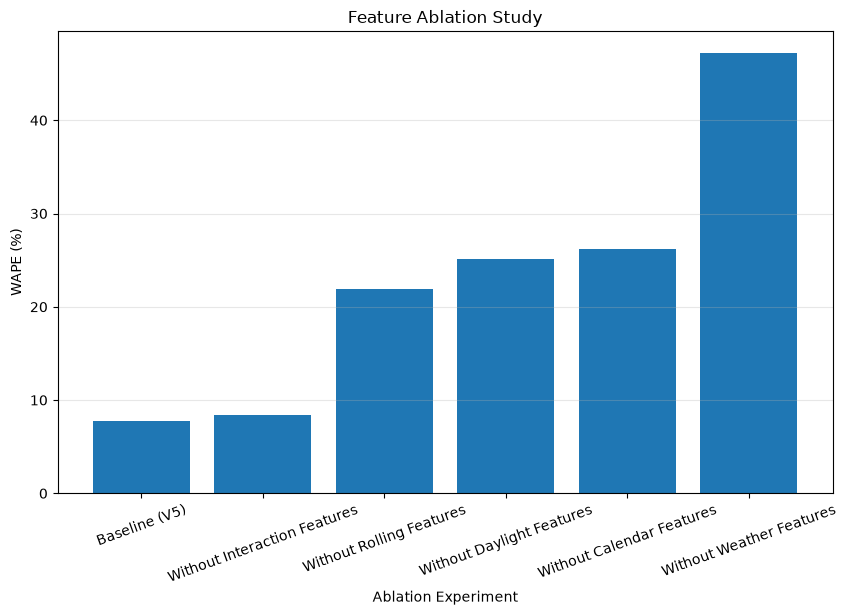

In [14]:
plt.figure(figsize=(10,6))

plt.bar(
    ablation_results["Experiment"],
    ablation_results["WAPE"]
)

plt.ylabel("WAPE (%)")
plt.xlabel("Ablation Experiment")
plt.title("Feature Ablation Study")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Discussion

The feature ablation study demonstrates the contribution of each engineered feature group to forecasting performance.

Removing interaction features resulted in only a minor increase in WAPE (7.79% to 8.42%), indicating that these features provided incremental improvements to the forecasting model.

In contrast, removing rolling statistical features substantially increased forecasting error to 21.87%, highlighting the importance of recent generation trends in predicting future solar generation.

The removal of daylight features further increased WAPE to 25.17%, demonstrating that explicit solar geometry information contributes significantly beyond calendar variables alone.

Removing calendar features increased WAPE to 26.21%, confirming that seasonal and temporal patterns remain important predictors even after incorporating weather observations.

The largest degradation occurred when weather features were removed, increasing WAPE to 47.18%. This finding confirms that meteorological variables form the foundation of the forecasting model, while subsequent feature engineering stages progressively refine predictive performance.

Overall, the ablation experiments validate the staged feature engineering strategy adopted throughout the GridSight pipeline.

## Conclusion

This notebook quantified the contribution of each feature engineering stage using systematic feature ablation.

The results show that weather variables are indispensable for accurate solar generation forecasting, while rolling statistics, daylight features, and calendar variables each provide substantial improvements in predictive performance. Interaction features contributed smaller but measurable gains to the final production model.

These findings complement the SHAP analysis presented in the previous notebook. While SHAP explained how the production model utilized individual features during prediction, the ablation study measured the performance impact of removing entire feature groups.

Together, these experiments provide both interpretability and empirical validation of the GridSight feature engineering pipeline.